In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from collections import Counter

from shapely.geometry import box
from shapely.ops import unary_union
from shapely import Polygon, MultiPolygon
import rioxarray

import os.path as path
import utils
import rioxarray as rxr
from rioxarray.merge import merge_arrays

import shapely
import xarray as xr
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
crop_type_files = utils.get_dataset_by_name("Crop Types")

In [3]:
gdf_polygons = gpd.read_file(path.join(utils.raw_data_dir, "NUTS_RG_01M_2021_4326.shp"))

In [4]:
with rasterio.open(crop_type_files[0]) as src:
    raster_crs = src.crs
gdf_polygons = gdf_polygons.to_crs(raster_crs)
assert raster_crs == gdf_polygons.crs

In [5]:
gdf_polygons = gdf_polygons[gdf_polygons["LEVL_CODE"] == 3]

In [6]:
print("building tile index...")
records = []
for i, filepath in enumerate(crop_type_files):
    if i % 100 == 0:
        print(f"processing file {i} of {len(crop_type_files)}")
    with rasterio.open(filepath) as src:
        records.append({
            "path": filepath,
            "geometry": box(*src.bounds),
            "crs": src.crs,
            "bounds": src.bounds
        })

print("Indexing...")
tile_index = gpd.GeoDataFrame(records, crs=records[0]["crs"])
print("Done.")

building tile index...
processing file 0 of 850
processing file 100 of 850
processing file 200 of 850
processing file 300 of 850
processing file 400 of 850
processing file 500 of 850
processing file 600 of 850
processing file 700 of 850
processing file 800 of 850
Indexing...
Done.


<Axes: >

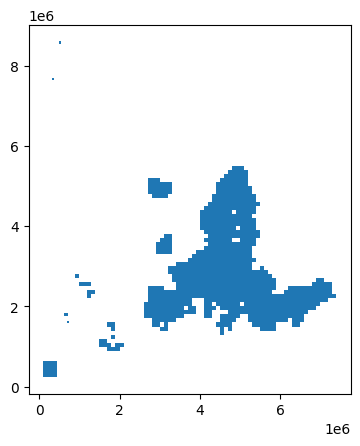

In [7]:
cropmap_boundary = shapely.ops.unary_union([box(*b) for b in tile_index["bounds"].values])
poly_is_inside_boundary = gdf_polygons.within(cropmap_boundary)
cropmap_boundary = gpd.GeoDataFrame(geometry=[cropmap_boundary], crs=raster_crs)
cropmap_boundary.plot()

In [8]:
gdf_polygons[~poly_is_inside_boundary]

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
1071,FRY30,3,FR,Guyane,Guyane,4.0,2,1,"MULTIPOLYGON (((-2617358.908 1019718.559, -261..."
1088,FRY20,3,FR,Martinique,Martinique,2.0,2,1,"MULTIPOLYGON (((-2663680.936 2539678.954, -266..."
1091,FRY40,3,FR,La Réunion,La Réunion,2.0,1,1,"POLYGON ((9981288.972 -3029239.216, 9982352.73..."
1261,FRY10,3,FR,Guadeloupe,Guadeloupe,4.0,2,1,"MULTIPOLYGON (((-2560849.867 2658762.001, -256..."
1337,FRY50,3,FR,Mayotte,Mayotte,2.0,2,1,"MULTIPOLYGON (((8744707.54 -2772192.722, 87447..."
...,...,...,...,...,...,...,...,...,...
2001,UKM64,3,UK,Na h-Eileanan Siar (Western Isles),Na h-Eileanan Siar (Western Isles),4.0,3,1,"MULTIPOLYGON (((3421917.42 4103329.591, 342191..."
2002,UKG37,3,UK,Sandwell,Sandwell,4.0,1,3,"POLYGON ((3512232.892 3339523.933, 3513019.349..."
2004,UKM77,3,UK,Perth & Kinross and Stirling,Perth & Kinross and Stirling,2.0,2,1,"MULTIPOLYGON (((3479787.512 3840721.294, 34801..."
2005,NO0B1,3,NO,Jan Mayen,Jan Mayen,3.0,3,1,"POLYGON ((3623747.621 5400386.841, 3624031.138..."


# Sanity check: which NUTS polygons are outside the raster?

- french overseas areas
- the northernmost parts of norway
- UK, which is not covered by the HRL

--> Filter is sensible and can be applied

In [9]:
gdf_polygons = gdf_polygons[poly_is_inside_boundary]
gdf_polygons = gdf_polygons.sort_values(by="NUTS_ID")
gdf_polygons["crop_profile"] = None

In [10]:
country_list = np.unique(gdf_polygons["CNTR_CODE"].values)

In [11]:
from time import time
def timer(start, stepname=""):
    end = time()
    print(f"{stepname}: {end - start:.4f} seconds")
    return end

def clip_raster(raster_path, geom_list):
    with rasterio.open(raster_path) as src:
        cropped_image, _ = mask(
            src,
            geom_list,
            crop=True
        )
        values, counts = np.unique(cropped_image, return_counts=True)
        return Counter(dict(zip(values.tolist(), counts.tolist())))

In [13]:
for cntr_code in country_list:
    out_file = path.join(utils.intermediate_data_dir, "nuts3_crop_profile", f"{cntr_code}.geojson")
    if path.isfile(out_file):
        print(f"Output file for country {cntr_code} already exists ({out_file})")
        print("skipping...")
        continue
    print("processing country: ", cntr_code)

    temp_df = gdf_polygons[gdf_polygons["CNTR_CODE"] == cntr_code]
        
    tile_dict = {}
    tile_data = xr.DataArray()

    for row_num, (row_idx, lau) in enumerate(temp_df.iterrows()):
        if row_num % 25 == 0:
            print(f"processing row {row_num} of {len(temp_df)}")
        lau_geom = lau.geometry
        matches = tile_index.sindex.query(lau_geom, predicate="intersects")    
        path_list = tile_index.iloc[matches]["path"].values


        global_counter = Counter()
        if isinstance(lau_geom, Polygon):
            geom_list = [lau_geom]
        elif isinstance(lau_geom, MultiPolygon):
            geom_list = list(lau_geom.geoms)
        else:
            raise ValueError("Non-Polygon geometry: ", type(lau_geom))
        
        with ThreadPoolExecutor(max_workers=len(path_list)) as executor:
            futures = [executor.submit(clip_raster, rasterfile, geom_list) for rasterfile in path_list]

            for future in as_completed(futures):
                global_counter += future.result()

        temp_df.at[row_idx, "crop_profile"]  = dict(global_counter)


    print("writing to file: ", out_file)
    temp_df.to_file(out_file)

processing country:  AL
processing row 0 of 12
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AL.geojson
processing country:  AT
processing row 0 of 35
processing row 25 of 35
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AT.geojson
processing country:  BE
processing row 0 of 44
processing row 25 of 44
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BE.geojson
processing country:  BG
processing row 0 of 28
processing row 25 of 28
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BG.geojson
processing country:  CH
processing row 0 of 26
processing row 25 of 26
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/CH.geojson
processing country:  CY
processing row 0 of 1
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_d